In [25]:
import pandas as pd
from pathlib import Path
from typing import List, Optional
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from torch import nn
import torch
from torch.utils.data import DataLoader, TensorDataset, Dataset
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import re

In [2]:

def merge_csv(
    folder_path: Optional[Path] = None, 
    file_paths: Optional[List[Path]] = None
) -> pd.DataFrame:
    """
    Merges CSV files from either a specified folder or a list of file paths.

    Args:
        folder_path: The path to the folder containing CSV files to merge.
        file_paths: A list of specific CSV file paths to merge.

    Returns:
        A single pandas DataFrame containing the merged data.

    Raises:
        ValueError: If neither or both `folder_path` and `file_paths` are provided,
                    or if no CSV files are found.
    """
    # 1. Input Validation (Guard Clauses)
    # This ensures the function is called correctly.
    if (folder_path is None and file_paths is None) or \
       (folder_path is not None and file_paths is not None):
        raise ValueError("Provide either 'folder_path' OR 'file_paths', not both/neither.")

    # 2. Determine the list of files based on the mode
    if folder_path:
        files = list(folder_path.glob("*.csv"))
    else:  # This block runs if file_paths is provided
        files = file_paths

    if files is []:
        raise ValueError("No CSV files found to merge.")

    # 3. Efficient Merging Logic
    # Reading all files into a list of DataFrames and concatenating once is
    # far more performant than concatenating one-by-one in a loop.
    df_list = (pd.read_csv(file) for file in files)
    return pd.concat(df_list, ignore_index=True)


def preprocess(df : pd.DataFrame, target_column = 'label', n_components = 0.99, batch_size = 256):
    feature_columns = [col for col in df.columns if col != target_column]
    
    le = ColumnTransformer(
        transformers = [
            ("encoder", OrdinalEncoder(), [target_column])
        ],
        remainder = "passthrough",
        verbose_feature_names_out = False
    )
    
    scaler = ColumnTransformer(
        transformers = [
            ("scaler", StandardScaler(), feature_columns)
        ],
        remainder = "passthrough",
        verbose_feature_names_out = False
    )
    
    pca = ColumnTransformer(
        transformers = [
            ("pca", PCA(), feature_columns)
        ],
        remainder = "passthrough",
        verbose_feature_names_out = False
    )
    
    pipeline = make_pipeline(le, scaler, pca)
    
    pipeline.set_output(transform = "pandas")

    df = pipeline.fit_transform(df)


    X = df.drop(target_column, axis=1).to_numpy()
    y = df[target_column].to_numpy()
    
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)

    loader = DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=True)
    
    return loader



class PreprocessedDataset(Dataset):
    def __init__(self, df: pd.DataFrame, target_column='label', n_components=0.99, pipeline = None):
        feature_columns = [col for col in df.columns if col != target_column]


        if pipeline is None:
            # Step 1: Encode target
            le = ColumnTransformer(
                transformers=[
                    ("encoder", OrdinalEncoder(), [target_column])
                ],
                remainder="passthrough",
                verbose_feature_names_out=False
            )
    
            # Step 2: Scale features
            scaler = ColumnTransformer(
                transformers=[
                    ("scaler", StandardScaler(), feature_columns)
                ],
                remainder="passthrough",
                verbose_feature_names_out=False
            )
    
            # Step 3: PCA for features
            pca = ColumnTransformer(
                transformers=[
                    ("pca", PCA(n_components=n_components), feature_columns)
                ],
                remainder="passthrough",
                verbose_feature_names_out=False
            )
    
            # Step 4: Create pipeline
            pipeline = Pipeline(
                steps = [
                    ('le', le),
                    ('scaler', scaler),
                    ('pca', pca)
                ]
            )
            pipeline.set_output(transform="pandas")
        
            
            # Step 5: Apply preprocessing
            df_transformed = pipeline.fit_transform(df)
            
        else:
            df_transformed = pipeline.transform(df)
            le = pipeline.named_steps['le']
            scaler = pipeline.named_steps['scaler']
            pca= pipeline.named_steps['pca']

        # Step 6: Save as tensors
        self.X = torch.tensor(
            df_transformed.drop(target_column, axis=1).to_numpy(),
            dtype=torch.float32
        )
        self.y = torch.tensor(
            df_transformed[target_column].to_numpy(),
            dtype=torch.long
        )

        self.le_ = le
        self.scaler_ = scaler
        self.pca_ = pca
        self.pipeline_ = pipeline

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [3]:
class CNNLSTMModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super(CNNLSTMModel, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3)  # Reduced from 64 to 32
        self.bn1 = nn.BatchNorm1d(32)
        self.pool = nn.MaxPool1d(2)
        self.dropout1 = nn.Dropout(0.4)  # Increased from 0.3 to 0.4
        self.lstm = nn.LSTM(
            input_size=32,  # Reduced from 64 to 32
            hidden_size=128,  # Reduced from 256 to 128
            num_layers=2,  # Reduced from 4 to 2
            batch_first=True,
            dropout=0.3,  # Increased from 0.2 to 0.3
            bidirectional=True
        )
        self.dropout2 = nn.Dropout(0.6)  # Increased from 0.5 to 0.6
        self.fc1 = nn.Linear(128 * 2, 32)  # Reduced from 64 to 32
        self.dropout3 = nn.Dropout(0.7)  # Increased from 0.6 to 0.7
        self.fc2 = nn.Linear(32, num_classes)  # Updated input size

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.pool(x)
        x = self.dropout1(x)
        x = x.permute(0, 2, 1)
        _, (h_n, _) = self.lstm(x)
        x = torch.cat((h_n[-2], h_n[-1]), dim=1)
        x = self.dropout2(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout3(x)
        return self.fc2(x)

In [4]:
DATA_PATH = Path('data')
SEED = 32
BATCH_SIZE = 256 # can try 128 again if testing result not well
PCA_COMPONENTS = 0.99
TARGET_COLUMN = 'label'

EPOCHS = 20
EARLY_STOPPING_PATIENCE = 3  # Reduced from 10
MODEL_PATH = Path("modelcheckpoints/best_model.pt")


if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"



In [54]:


paths = np.array(list(DATA_PATH.glob('wifisignal_data_*.csv')))
pattern = r'wifisignal_data_([a-zA-Z]+)_'

labels = []
for path in paths:
    match = re.search(pattern, path.name)
    if match:
        labels.append(match.group(1))
labels = np.array(labels)



for i in range(5):

    train_paths,test_paths = train_test_split(paths, train_size = 20, test_size = 5, stratify = labels)
    
    train_df = merge_csv(file_paths = train_paths)
    train_ds = PreprocessedDataset(train_df, target_column = TARGET_COLUMN, n_components = PCA_COMPONENTS)
    train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle = True)
    X_train, y_train = train_ds.X, train_ds.y

    val_df = merge_csv(file_paths = test_paths)
    val_ds = PreprocessedDataset(val_df, target_column = TARGET_COLUMN, n_components = PCA_COMPONENTS, pipeline = train_ds.pipeline_)
    val_loader = DataLoader(val_ds, batch_size = BATCH_SIZE)
    X_val, y_val = val_ds.X, val_ds.y

    le = train_ds.le_
    
    print("SAMPLE", i+1)
    print("Train Paths: ")
    for path in train_paths:
        print(path.name)
    
    print("Test Paths: ")
    for path in test_paths:
        print(path.name)
    
    patience = EARLY_STOPPING_PATIENCE
    best_val_loss = float('inf')  # Initialize best validation loss
    
    model = CNNLSTMModel(input_size=X_train.shape[1], num_classes=len(le.named_transformers_["encoder"].categories_[0]))
    model = model.to(device)
    
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train.numpy())
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
    
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1, weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    scaler_amp = torch.amp.GradScaler('cuda')
    
    # Store all metrics for plotting
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    epochs_completed = []
    
    for epoch in range(EPOCHS):
        # Training phase
        model.train()
        running_loss = 0.0
        train_correct, train_total = 0, 0
        
        progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
        for xb, yb in progress:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                preds = model(xb)
                loss = criterion(preds, yb)
            scaler_amp.scale(loss).backward()
            scaler_amp.step(optimizer)
            scaler_amp.update()
            running_loss += loss.item()
            
            # Calculate training accuracy
            train_correct += (preds.argmax(dim=1) == yb).sum().item()
            train_total += yb.size(0)
    
        train_loss = running_loss / len(train_loader)
        train_acc = train_correct / train_total
    
        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        y_preds, y_true = [], []
    
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                with torch.amp.autocast('cuda'):
                    preds = model(xb)
                    loss = criterion(preds, yb)
                val_loss += loss.item()
                val_correct += (preds.argmax(dim=1) == yb).sum().item()
                val_total += yb.size(0)
                y_preds.extend(preds.argmax(dim=1).cpu().numpy())
                y_true.extend(yb.cpu().numpy())
    
        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        scheduler.step()
    
        # Store metrics
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        epochs_completed.append(epoch + 1)
    
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
        # Improved early stopping logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            fold_model_path = f"{MODEL_PATH}"
            torch.save(model.state_dict(), fold_model_path)
            patience = EARLY_STOPPING_PATIENCE
            print(f"New best validation loss: {best_val_loss:.4f} - Model saved")
        else:
            patience -= 1
            print(f"No improvement. Patience: {patience}")
            if patience == 0:
                print("Early stopping triggered.")
                break

SAMPLE 1
Train Paths: 
wifisignal_data_standing_20250529_154346.csv
wifisignal_data_standing_20250529_152837.csv
wifisignal_data_sitting_20250528_152209.csv
wifisignal_data_walking_20250528_172759.csv
wifisignal_data_sleeping_20250528_165213.csv
wifisignal_data_walking_20250529_164630.csv
wifisignal_data_sitting_20250528_153421.csv
wifisignal_data_walking_20250529_162416.csv
wifisignal_data_sleeping_20250528_164158.csv
wifisignal_data_walking_20250529_161311.csv
wifisignal_data_standing_20250528_174055.csv
wifisignal_data_walking_20250529_163540.csv
wifisignal_data_sleeping_20250528_162231.csv
wifisignal_data_standing_20250529_151536.csv
wifisignal_data_standing_20250529_155856.csv
wifisignal_data_falling_20250528_183631.csv
wifisignal_data_standing_20250529_153009.csv
wifisignal_data_sitting_20250528_151248.csv
wifisignal_data_falling_20250528_180631.csv
wifisignal_data_falling_20250528_181944.csv
Test Paths: 
wifisignal_data_walking_20250528_171954.csv
wifisignal_data_falling_2025052

Epoch 1, Train Loss: 1.6064, Train Acc: 0.2210, Val Loss: 1.5700, Val Acc: 0.2932
New best validation loss: 1.5700 - Model saved


Epoch 2, Train Loss: 1.4582, Train Acc: 0.3668, Val Loss: 1.4958, Val Acc: 0.3159
New best validation loss: 1.4958 - Model saved


Epoch 3, Train Loss: 1.3433, Train Acc: 0.4482, Val Loss: 1.5100, Val Acc: 0.3159
No improvement. Patience: 2


Epoch 4, Train Loss: 1.2698, Train Acc: 0.4956, Val Loss: 1.4676, Val Acc: 0.3596
New best validation loss: 1.4676 - Model saved


...

Epoch 1, Train Loss: 1.5908, Train Acc: 0.2272, Val Loss: 1.5145, Val Acc: 0.2626
New best validation loss: 1.5145 - Model saved


Epoch 2, Train Loss: 1.4700, Train Acc: 0.3265, Val Loss: 1.4336, Val Acc: 0.3083
New best validation loss: 1.4336 - Model saved


Epoch 3, Train Loss: 1.4238, Train Acc: 0.3604, Val Loss: 1.4634, Val Acc: 0.3064
No improvement. Patience: 2


Epoch 4, Train Loss: 1.3948, Train Acc: 0.3832, Val Loss: 1.4843, Val Acc: 0.3333
No improvement. Patience: 1


Epoch 5, Train Loss: 1.3656, Train Acc: 0.4072, Val Loss: 1.5640, Val Acc: 0.3146
No improvement. Patience: 0
Early stopping triggered.


In [41]:
train_test_split(paths, train_size = 20, test_size = 5, stratify = labels)

[array([WindowsPath('data/wifisignal_data_falling_20250528_175224.csv'),
        WindowsPath('data/wifisignal_data_sleeping_20250528_150513.csv'),
        WindowsPath('data/wifisignal_data_sitting_20250528_153130.csv'),
        WindowsPath('data/wifisignal_data_standing_20250528_173747.csv'),
        WindowsPath('data/wifisignal_data_sleeping_20250528_163413.csv'),
        WindowsPath('data/wifisignal_data_walking_20250529_162247.csv'),
        WindowsPath('data/wifisignal_data_standing_20250528_155235.csv'),
        WindowsPath('data/wifisignal_data_falling_20250528_184231.csv'),
        WindowsPath('data/wifisignal_data_walking_20250528_165939.csv'),
        WindowsPath('data/wifisignal_data_standing_20250528_160057.csv'),
        WindowsPath('data/wifisignal_data_walking_20250528_142002.csv'),
        WindowsPath('data/wifisignal_data_sitting_20250528_153734.csv'),
        WindowsPath('data/wifisignal_data_standing_20250528_155456.csv'),
        WindowsPath('data/wifisignal_data_fal

In [50]:
np.apply_along_axis(lambda x : x.name, axis = 0, arr = train_paths)

AttributeError: 'numpy.ndarray' object has no attribute 'name'

In [53]:
train_paths[0].name

'wifisignal_data_sleeping_20250528_165337.csv'

In [32]:
all_labels

array(['falling', 'falling', 'falling', 'falling', 'falling', 'sitting',
       'sitting', 'sitting', 'sitting', 'sitting', 'sleeping', 'sleeping',
       'sleeping', 'sleeping', 'sleeping', 'standing', 'standing',
       'standing', 'standing', 'standing', 'walking', 'walking',
       'walking', 'walking', 'walking'], dtype=object)

In [11]:
model.eval()

torch.save(model.state_dict(), "modelcheckpoints/notTrainTestSplit.pt")

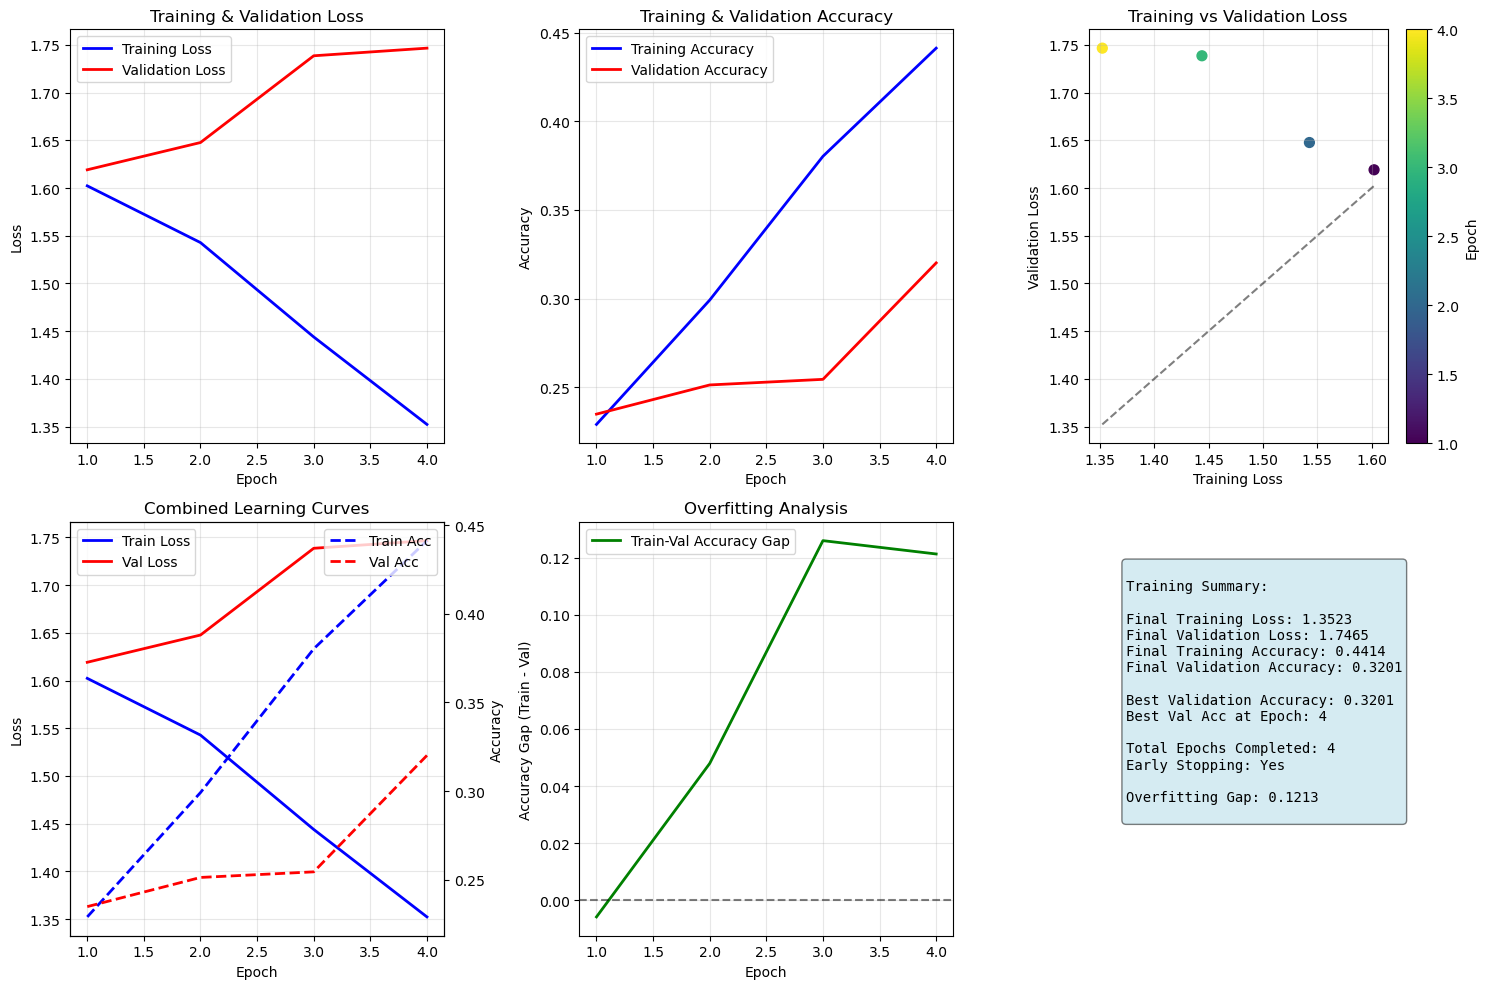

=== Detailed Training Metrics ===
Epoch  Train Loss   Train Acc    Val Loss     Val Acc      Gap     
--------------------------------------------------------------------
1      1.6023       0.2289       1.6191       0.2347       -0.0058 
2      1.5428       0.2991       1.6477       0.2512       0.0479  
3      1.4440       0.3803       1.7385       0.2544       0.1259  
4      1.3523       0.4414       1.7465       0.3201       0.1213  


In [12]:
# Create comprehensive training metrics visualization
plt.figure(figsize=(15, 10))

# 1. Loss curves
plt.subplot(2, 3, 1)
plt.plot(epochs_completed, train_losses, 'b-', label='Training Loss', linewidth=2)
plt.plot(epochs_completed, val_losses, 'r-', label='Validation Loss', linewidth=2)
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Accuracy curves
plt.subplot(2, 3, 2)
plt.plot(epochs_completed, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
plt.plot(epochs_completed, val_accuracies, 'r-', label='Validation Accuracy', linewidth=2)
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Training vs Validation Loss (scatter plot)
plt.subplot(2, 3, 3)
plt.scatter(train_losses, val_losses, c=epochs_completed, cmap='viridis', s=50)
plt.plot([min(train_losses), max(train_losses)], [min(train_losses), max(train_losses)], 'k--', alpha=0.5)
plt.title('Training vs Validation Loss')
plt.xlabel('Training Loss')
plt.ylabel('Validation Loss')
plt.colorbar(label='Epoch')
plt.grid(True, alpha=0.3)

# 4. Learning curves (combined)
plt.subplot(2, 3, 4)
ax1 = plt.gca()
ax1.plot(epochs_completed, train_losses, 'b-', linewidth=2, label='Train Loss')
ax1.plot(epochs_completed, val_losses, 'r-', linewidth=2, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='k')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_completed, train_accuracies, 'b--', linewidth=2, label='Train Acc')
ax2.plot(epochs_completed, val_accuracies, 'r--', linewidth=2, label='Val Acc')
ax2.set_ylabel('Accuracy', color='k')
ax2.legend(loc='upper right')
plt.title('Combined Learning Curves')

# 5. Overfitting analysis
plt.subplot(2, 3, 5)
gap = np.array(train_accuracies) - np.array(val_accuracies)
plt.plot(epochs_completed, gap, 'g-', linewidth=2, label='Train-Val Accuracy Gap')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.title('Overfitting Analysis')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap (Train - Val)')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Metrics summary table
plt.subplot(2, 3, 6)
plt.axis('off')

# Create summary statistics
final_train_loss = train_losses[-1]
final_val_loss = val_losses[-1]
final_train_acc = train_accuracies[-1]
final_val_acc = val_accuracies[-1]
best_val_acc = max(val_accuracies)
best_val_acc_epoch = epochs_completed[np.argmax(val_accuracies)]

summary_text = f"""
Training Summary:

Final Training Loss: {final_train_loss:.4f}
Final Validation Loss: {final_val_loss:.4f}
Final Training Accuracy: {final_train_acc:.4f}
Final Validation Accuracy: {final_val_acc:.4f}

Best Validation Accuracy: {best_val_acc:.4f}
Best Val Acc at Epoch: {best_val_acc_epoch}

Total Epochs Completed: {len(epochs_completed)}
Early Stopping: {'Yes' if len(epochs_completed) < EPOCHS else 'No'}

Overfitting Gap: {final_train_acc - final_val_acc:.4f}
"""

plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.5))

plt.tight_layout()
plt.show()

# Print detailed metrics
print("=== Detailed Training Metrics ===")
print(f"{'Epoch':<6} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} {'Gap':<8}")
print("-" * 68)
for i in range(len(epochs_completed)):
    gap = train_accuracies[i] - val_accuracies[i]
    print(f"{epochs_completed[i]:<6} {train_losses[i]:<12.4f} {train_accuracies[i]:<12.4f} "
          f"{val_losses[i]:<12.4f} {val_accuracies[i]:<12.4f} {gap:<8.4f}")

100%|████████████████████████████████████████████████████████████████████████████████| 576/576 [00:07<00:00, 73.93it/s]


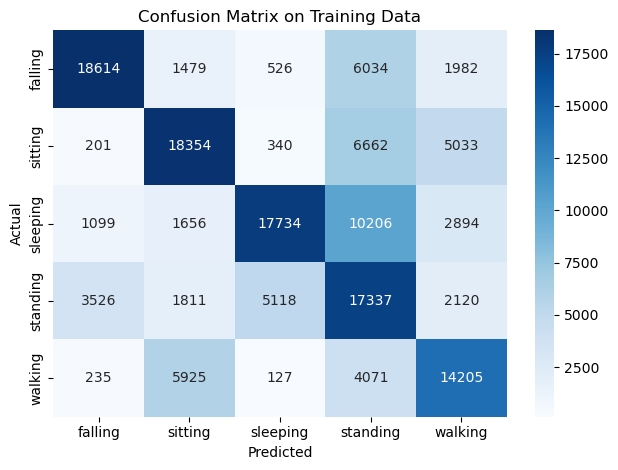

In [13]:
model.to(device)

categories = le.named_transformers_['encoder'].categories_[0]

cm = np.zeros((5,5))

for X_batch, y_batch in tqdm(train_loader):
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    pred = model(X_batch).argmax(dim = 1)
    pred = pred.to('cpu')
    y_batch = y_batch.to('cpu')
    cm += confusion_matrix(y_batch, pred, labels = np.arange(len(categories)))

fig, ax = plt.subplots()
cm_df = pd.DataFrame(cm, columns = categories, index = categories, dtype = int)

ax.set_title("Confusion Matrix on Training Data")

sns.heatmap(cm_df, cmap = "Blues", annot = True, fmt = 'd', ax = ax)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()

plt.show()

100%|████████████████████████████████████████████████████████████████████████████████| 311/311 [00:04<00:00, 73.84it/s]


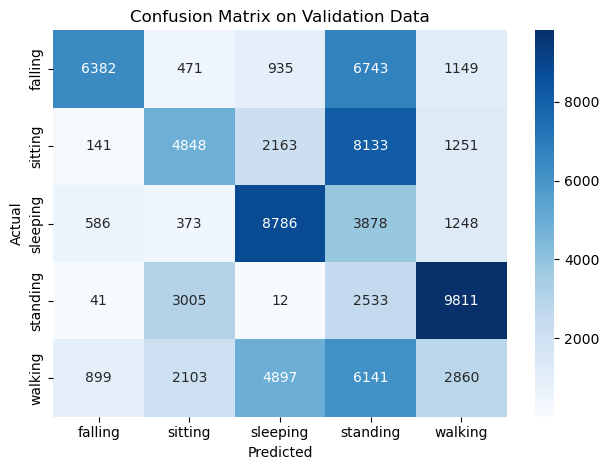

In [14]:
model.to(device)

categories = le.named_transformers_['encoder'].categories_[0]

cm = np.zeros((5,5))

for X_batch, y_batch in tqdm(val_loader):
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    pred = model(X_batch).argmax(dim = 1)
    pred = pred.to('cpu')
    y_batch = y_batch.to('cpu')
    cm += confusion_matrix(y_batch, pred, labels = np.arange(len(categories)))

fig, ax = plt.subplots()
cm_df = pd.DataFrame(cm, columns = categories, index = categories, dtype = int)

ax.set_title("Confusion Matrix on Validation Data")

sns.heatmap(cm_df, cmap = "Blues", annot = True, fmt = 'd', ax = ax)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()

plt.show()